In [ ]:
### Target: County-Level hourly MW

In [ ]:
!pip install shap

In [ ]:
!pip install pandas pyarrow

In [ ]:
!pip install lightgbm

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read in the data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/train_rolling_windows/'
    location = directory + filename+'.parquet'
    df = pd.read_parquet(location)
    return df

In [ ]:
## Read in data
df=read_file('train_window_1')
df.columns

Index(['date', 'county', 'cdd65', 'cdd65_pop', 'cdd75', 'cdd75_pop',
       'cloud_cover_pct_mean', 'cloud_cover_pct_pop', 'dpt_afternoon_k_mean',
       'dpt_afternoon_k_pop', 'dpt_morning_k_mean', 'dpt_morning_k_pop',
       'hdd65', 'hdd65_pop', 'spfh_peak_kgkg_mean', 'spfh_peak_kgkg_pop',
       'tavg_k', 'tmax_k', 'tmax_k_pop', 'tmin_k', 'tmin_k_pop', 'trange_k',
       'wind_low_ms_mean', 'wind_low_ms_pop', 'wind_peak_ms_mean',
       'wind_peak_ms_pop', 'real_data_urma', 'staying_total', 'entering_total',
       'leaving_total', 'real_data_commuting', 'cuml_count', 'cuml_sq_foot',
       'cuml_utility_cap', 'cuml_dc_load', 'real_data_data_centers',
       'electricity_usage', 'public_level_1', 'shared_private_level_1',
       'public_level_2', 'shared_private_level_2', 'public_dc_fast',
       'shared_private_dc_fast', 'total', 'real_data_ev_charging', 'bev',
       'phev', 'fcev', 'real_data_ev_poplution', 'est_median_income',
       'real_data_income', 'total_pop', 'household_

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42398 entries, 0 to 42397
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    42398 non-null  datetime64[ns]
 1   county                  42398 non-null  object        
 2   cdd65                   42398 non-null  float32       
 3   cdd65_pop               42398 non-null  float32       
 4   cdd75                   42398 non-null  float32       
 5   cdd75_pop               42398 non-null  float32       
 6   cloud_cover_pct_mean    42398 non-null  float32       
 7   cloud_cover_pct_pop     42398 non-null  float32       
 8   dpt_afternoon_k_mean    42398 non-null  float32       
 9   dpt_afternoon_k_pop     42398 non-null  float32       
 10  dpt_morning_k_mean      42398 non-null  float32       
 11  dpt_morning_k_pop       42398 non-null  float32       
 12  hdd65                   42398 non-null  float3

In [ ]:
## Fix DataTypes
df['date']=pd.to_datetime(df['date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42398 entries, 0 to 42397
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    42398 non-null  datetime64[ns]
 1   county                  42398 non-null  object        
 2   cdd65                   42398 non-null  float32       
 3   cdd65_pop               42398 non-null  float32       
 4   cdd75                   42398 non-null  float32       
 5   cdd75_pop               42398 non-null  float32       
 6   cloud_cover_pct_mean    42398 non-null  float32       
 7   cloud_cover_pct_pop     42398 non-null  float32       
 8   dpt_afternoon_k_mean    42398 non-null  float32       
 9   dpt_afternoon_k_pop     42398 non-null  float32       
 10  dpt_morning_k_mean      42398 non-null  float32       
 11  dpt_morning_k_pop       42398 non-null  float32       
 12  hdd65                   42398 non-null  float3

## NAN Analysis

In [ ]:
# Count nulls per column
null_counts = df.isna().sum().sort_values(ascending=False)

# Show only columns with nulls
null_counts[null_counts > 0]


,0
holiday,41180
shared_private_level_2,26448
real_data_ev_charging,26448
total,26448
public_level_1,26448
public_level_2,26448
public_dc_fast,26448
shared_private_dc_fast,26448
shared_private_level_1,26448


In [ ]:
null_percent = (df.isna().mean() * 100).sort_values(ascending=False)

null_percent[null_percent > 0]


,0
holiday,97.127223
shared_private_level_2,62.380301
real_data_ev_charging,62.380301
total,62.380301
public_level_1,62.380301
public_level_2,62.380301
public_dc_fast,62.380301
shared_private_dc_fast,62.380301
shared_private_level_1,62.380301


In [ ]:
df[df["date"].isna()].head(10)


,date,county,cdd65,cdd65_pop,cdd75,cdd75_pop,cloud_cover_pct_mean,cloud_cover_pct_pop,dpt_afternoon_k_mean,dpt_afternoon_k_pop,...,occupied,real_data_population,area,year,month,day_of_year,day_of_week,quarter,holiday,is_holiday


In [ ]:
null_counts = (df.groupby("county")["electricity_usage"].apply(lambda x: x.isna().sum()).sort_values(ascending=False))

null_counts[null_counts > 0].sort_values(ascending=False)


,electricity_usage
county,


## Feature Store

In [ ]:
selected_features = [
    # CATEGORICAL
    "county",
    "day_of_week",

    # CALENDAR
    "quarter",
    "month",
    "is_holiday",

    # TEMPERATURE
    "tmax_k_pop",
    "tmin_k_pop",

    # DEGREE DAYS
    "hdd65_pop",
    "cdd65_pop",
    "cdd75_pop",

    # ROLLING WEATHER
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "cdd65_pop_roll14",   # new
    "hdd65_pop_roll14",   # new
    "tmax_k_pop_roll5_max",
    "tmax_k_pop_roll7_mean",

    # HUMIDITY
    "spfh_peak_kgkg_pop",

    # WIND
    "wind_peak_ms_pop",

    # MOBILITY (fixed at 2019 baseline)
    "staying_total",
    "entering_total",
    "leaving_total",

    # DATA CENTERS
    "cuml_count",
    "cuml_sq_foot",
    "cuml_dc_load",

    # EVs (drop fcev — spurious)
    "bev",
    "phev",

    # SOCIOECONOMIC
    "est_median_income",
    "total_pop",
]

target = "elec_per_capita"
cat_cols = ["county", "day_of_week"]

print(f"Features: {len(selected_features)}")
print(f"Target: {target}")

Features: 28
Target: elec_per_capita


## Identify Target, Categorical and Cols on full dataset

In [ ]:
## Setting up Target / Data Types

target = "electricity_usage"
cat_cols=["county","day_of_week"]

## Light GBM Categorical Variables

## Feature Engineering

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [ ]:
# def run_window(train_df, val_df, selected_features, params):

#     X_train = train_df[selected_features]
#     y_train = train_df[target]
#     X_val   = val_df[selected_features]
#     y_val   = val_df[target]

#     model = lgb.LGBMRegressor(**params)

#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric="rmse",
#         callbacks=[lgb.early_stopping(50, verbose=False)]
#     )

#     preds = model.predict(X_val, num_iteration=model.best_iteration_)
#     score = rmse(y_val, preds)

#     return model, score, model.best_iteration_

# params = dict(
#     n_estimators=5000,
#     learning_rate=0.03,
#     num_leaves=64,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
# )

In [ ]:
train_1 = read_file('train_window_1')
train_2 = read_file('train_window_2')
val_1 = read_file('val_window_1')
val_2 = read_file('val_window_2')

print("train_1:", train_1.shape)
print("train_2:", train_2.shape)
print("val_1:", val_1.shape)
print("val_2:", val_2.shape)


train_1: (42398, 70)
train_2: (42398, 70)
val_1: (21170, 70)
val_2: (21170, 70)


In [ ]:
# normalize target by population
for d in [train_1, train_2, val_1, val_2]:
    d['date'] = pd.to_datetime(d['date'])
    d['elec_per_capita'] = d['electricity_usage'] / d['total_pop']

print("train_1:", train_1.shape)
print("elec_per_capita sample:", train_1['elec_per_capita'].describe())

train_1: (42398, 78)
elec_per_capita sample: count    42398.000000
mean         0.018993
std          0.003340
min          0.010058
25%          0.016700
50%          0.018065
75%          0.020905
max          0.040170
Name: elec_per_capita, dtype: float64


In [ ]:
ROLLING_SPECS = [
    ("cdd65_pop_roll5",      "cdd65_pop",  5,  "sum"),
    ("hdd65_pop_roll5",      "hdd65_pop",  5,  "sum"),
    ("tmax_k_pop_roll5_max", "tmax_k_pop", 5,  "max"),
    ("tmax_k_pop_roll7_mean","tmax_k_pop", 7,  "mean"),
    ("cdd65_pop_roll14",     "cdd65_pop",  14, "sum"),   # new - longer heat persistence
    ("hdd65_pop_roll14",     "hdd65_pop",  14, "sum"),   # new
]

def add_rolling_features(df):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)
    for new_col, src_col, window, agg in ROLLING_SPECS:
        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )
    return df

# compute 2019 mobility baseline from train data
mobility_baseline = (
    train_1[train_1['date'].dt.year == 2019]
    .groupby(['county', 'day_of_week'])[['staying_total','entering_total','leaving_total']]
    .median()
    .reset_index()
)
print("Mobility baseline shape:", mobility_baseline.shape)
print(mobility_baseline.head())

# --- apply to all your datasets ---
datasets = {
    "train_1": train_1,
    "train_2": train_2,
    "val_1": val_1,
    "val_2": val_2,
}

for name, d in datasets.items():
    datasets[name] = add_rolling_features(d)
    print(f"{name}: added rolling cols -> shape={datasets[name].shape}")

# overwrite your variables (optional convenience)
train_1 = datasets["train_1"]
train_2 = datasets["train_2"]
val_1   = datasets["val_1"]
val_2   = datasets["val_2"]


/tmp/ipython-input-1105756635.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['county', 'day_of_week'])[['staying_total','entering_total','leaving_total']]
/tmp/ipython-input-1105756635.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)


Mobility baseline shape: (406, 5)
    county day_of_week  staying_total  entering_total  leaving_total
0  Alameda      Friday  371037.000000   434023.000000  437366.000000
1  Alameda      Monday  371025.361644   433982.726027  437432.427397
2  Alameda    Saturday  371033.120548   434009.575342  437388.142466
3  Alameda      Sunday  371029.241096   433996.150685  437410.284932
4  Alameda    Thursday  371040.879452   434036.424658  437343.857534
train_1: added rolling cols -> shape=(42398, 80)


/tmp/ipython-input-1105756635.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)
/tmp/ipython-input-1105756635.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)


train_2: added rolling cols -> shape=(42398, 80)
val_1: added rolling cols -> shape=(21170, 80)
val_2: added rolling cols -> shape=(21170, 80)


/tmp/ipython-input-1105756635.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("county", sort=False)


In [ ]:
datasets = {'train_1': train_1, 'train_2': train_2, 'val_1': val_1, 'val_2': val_2}

for name, df in datasets.items():
    df = df.drop(columns=['staying_total', 'entering_total', 'leaving_total'])
    df = df.merge(mobility_baseline, on=['county', 'day_of_week'], how='left')
    datasets[name] = df
    print(f"{name}: {df.shape} — mobility NaNs: {df[['staying_total','entering_total','leaving_total']].isnull().sum().sum()}")

train_1 = datasets['train_1']
train_2 = datasets['train_2']
val_1   = datasets['val_1']
val_2   = datasets['val_2']

train_1: (42398, 80) — mobility NaNs: 0
train_2: (42398, 80) — mobility NaNs: 0
val_1: (21170, 80) — mobility NaNs: 0
val_2: (21170, 80) — mobility NaNs: 0


In [ ]:
cat_cols = ["county", "day_of_week"]

def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        if c in train_df.columns and c in val_df.columns:
            train_df[c] = train_df[c].astype("category")
            val_df[c]   = val_df[c].astype("category")
            # align val categories to train categories
            val_df[c] = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df


In [ ]:
def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        val_df[c]   = val_df[c].astype("category")
        val_df[c]   = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_window(train_df, val_df, features, params):
    X_train = train_df[features]
    y_train = train_df[target]
    X_val   = val_df[features]
    y_val   = val_df[target]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    score = rmse(y_val, preds)
    return model, score, preds, model.best_iteration_

params = dict(
    n_estimators=5000,
    learning_rate=0.01,       # slowed down from 0.03
    num_leaves=64,
    min_child_samples=50,     # regularize — prevents overfitting small counties
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

train_1, val_1 = set_and_align_categories(train_1, val_1)
train_2, val_2 = set_and_align_categories(train_2, val_2)

model1, rmse1, preds1, it1 = run_window(train_1, val_1, selected_features, params)
model2, rmse2, preds2, it2 = run_window(train_2, val_2, selected_features, params)

print(f"""
rmse_window_1 (per capita): {rmse1:.6f}
rmse_window_2 (per capita): {rmse2:.6f}
avg_rmse:                   {(rmse1+rmse2)/2:.6f}
best_iters:                 ({it1}, {it2})
""")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005007 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5949
[LightGBM] [Info] Number of data points in the train set: 42398, number of used features: 28
[LightGBM] [Info] Start training from score 0.018993
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5949
[LightGBM] [Info] Number of data points in the train set: 42398, number of used features: 28
[LightGBM] [Info] Start training from score 0.019296

rmse_window_1 (per capita): 0.002486
rmse_window_2 (per capita): 0.003002
avg_rmse:                   0.002744
best_iters:                 (488, 118)



In [ ]:
# convert per-capita predictions back to MWh
val_1['preds_mwh'] = preds1 * val_1['total_pop']
val_2['preds_mwh'] = preds2 * val_2['total_pop']

def rmse_mwh(df):
    return np.sqrt(mean_squared_error(df['electricity_usage'], df['preds_mwh']))

def pct_of_mean(df):
    return 100 * rmse_mwh(df) / df['electricity_usage'].mean()

def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['electricity_usage'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['electricity_usage'], weights=w)
    return 100 * wrmse / wmean

print("=== NEW MODEL ===")
print(f"RMSE MWh  w1: {rmse_mwh(val_1):,.0f}   w2: {rmse_mwh(val_2):,.0f}   avg: {(rmse_mwh(val_1)+rmse_mwh(val_2))/2:,.0f}")
print(f"RMSE % mean  w1: {pct_of_mean(val_1):.1f}%  w2: {pct_of_mean(val_2):.1f}%")
print(f"Pop-wtd RMSE% w1: {pop_weighted_rmse_pct(val_1):.1f}%  w2: {pop_weighted_rmse_pct(val_2):.1f}%")

print("\n=== OLD MODEL (for reference) ===")
print(f"RMSE MWh avg: 4,885")
print(f"RMSE % mean: 37.6%")
print(f"Pop-wtd RMSE%: 21.9%")

=== NEW MODEL ===
RMSE MWh  w1: 3,647   w2: 4,714   avg: 4,181
RMSE % mean  w1: 28.0%  w2: 35.1%
Pop-wtd RMSE% w1: 16.6%  w2: 20.9%

=== OLD MODEL (for reference) ===
RMSE MWh avg: 4,885
RMSE % mean: 37.6%
Pop-wtd RMSE%: 21.9%


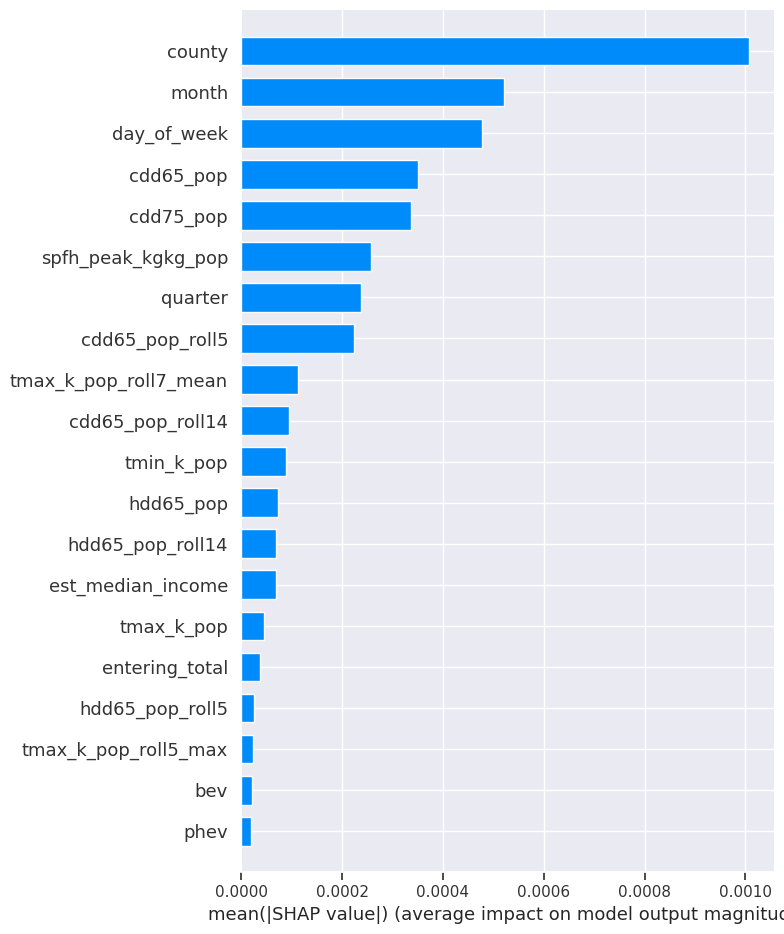

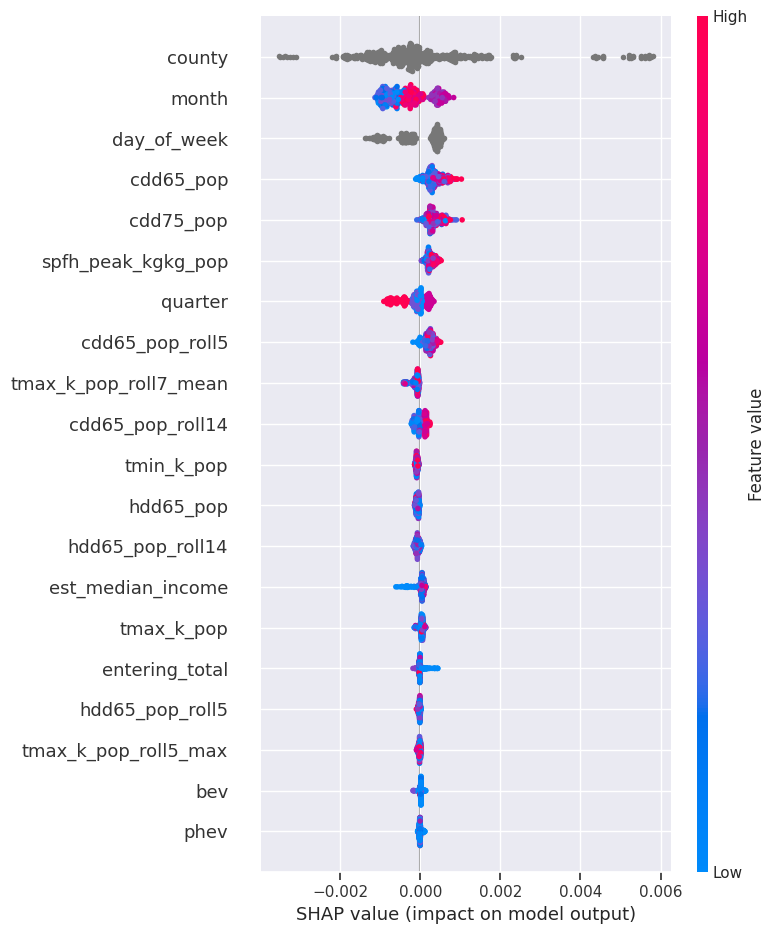

In [ ]:
import shap

explainer = shap.TreeExplainer(model1)
shap_sample = val_1[selected_features].sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar")
shap.summary_plot(shap_values, shap_sample)

In [ ]:
import joblib
import os

os.makedirs('/content/drive/My Drive/210_capstone/models', exist_ok=True)

joblib.dump(model1, '/content/drive/My Drive/210_capstone/models/lgbm_w1_v2.pkl')
joblib.dump(model2, '/content/drive/My Drive/210_capstone/models/lgbm_w2_v2.pkl')

# save the feature list and mobility baseline too — critical for inference
joblib.dump(selected_features, '/content/drive/My Drive/210_capstone/models/selected_features_v2.pkl')
mobility_baseline.to_parquet('/content/drive/My Drive/210_capstone/models/mobility_baseline_2019.parquet')

print("Saved:")
print("  lgbm_w1_v2.pkl")
print("  lgbm_w2_v2.pkl")
print("  selected_features_v2.pkl")
print("  mobility_baseline_2019.parquet")

Saved:
  lgbm_w1_v2.pkl
  lgbm_w2_v2.pkl
  selected_features_v2.pkl
  mobility_baseline_2019.parquet


# IDK OLD BELOW

In [ ]:
def weighted_rmse(y_true, y_pred, weights):
    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))


In [ ]:
import numpy as np

def weighted_rmse(y_true, y_pred, weights):
    weights = np.asarray(weights)
    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))

preds1 = model1.predict(
    val_1[selected_features],
    num_iteration=model1.best_iteration_
)

w_rmse1 = weighted_rmse(
    val_1["electricity_usage"].values,
    preds1,
    val_1["total_pop"].values
)

print("Population-weighted RMSE (window 1):", w_rmse1)


Population-weighted RMSE (window 1): 15743.89290304855


In [ ]:
preds2 = model2.predict(
    val_2[selected_features],
    num_iteration=model2.best_iteration_
)

w_rmse2 = weighted_rmse(
    val_2["electricity_usage"].values,
    preds2,
    val_2["total_pop"].values
)

print("Population-weighted RMSE (window 2):", w_rmse2)
print("Avg population-weighted RMSE:", (w_rmse1 + w_rmse2)/2)


Population-weighted RMSE (window 2): 15392.499693608532
Avg population-weighted RMSE: 15568.196298328541


In [ ]:
w_mean_load_1 = np.average(val_1["electricity_usage"].values, weights=val_1["total_pop"].values)
print("Pop-weighted mean load (w1):", w_mean_load_1)
print("Pop-weighted RMSE % (w1):", 100 * w_rmse1 / w_mean_load_1)


Pop-weighted mean load (w1): 71842.76339836429
Pop-weighted RMSE % (w1): 21.914375447600065


## OLD Split into Test/Train/Val

In [ ]:
## Rolling Window Cols

# Sort first (critical)
df = df.sort_values(["county", "date"])

df["cdd65_pop_roll5"] = (
    df.groupby("county")["cdd65_pop"]
      .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

df["hdd65_pop_roll5"] = (
    df.groupby("county")["hdd65_pop"]
      .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

df["tmax_k_pop_roll5_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=5, min_periods=1).max())
)

df["tmax_k_pop_roll3_mean"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["tmax_k_pop_roll7_mean"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df["tmax_k_pop_roll3_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(3, min_periods=1).max())
)

df["tmax_k_pop_roll7_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(7, min_periods=1).max())
)

In [ ]:
# train_end = pd.Timestamp("2018-09-01")
# val_end   = pd.Timestamp("2018-11-01")

# df = df.sort_values(["date"] + [c for c in "county" if c in df.columns])


# train_df = df[df["date"] < train_end]
# val_df   = df[(df["date"] >= train_end) & (df["date"] < val_end)]
# test_df  = df[df["date"] >= val_end]


In [ ]:
# train_shape = train_df.shape
# val_shape = val_df.shape
# test_shape =test_df.shape
# print(f"Shapes:\nTrain:{train_shape}\nVal:{val_shape}\nTest:{test_shape}\n")

In [ ]:
## Remove target cols and date cols (not useful for lightGBM)
df = df.copy() ## copy